In [1]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

import torch
import numpy as np
import pandas as pd
import os
import sklearn.model_selection

from flonacomldft.data_utils import get_path


In [2]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, layerdims, activation=torch.nn.LeakyReLU(), init_scale=None, shift=None):
        super(MLP, self).__init__()
        self.layerdims = layerdims
        self.activation = activation
        linears = [nn.Linear(layerdims[i], layerdims[i + 1]) for i in range(len(layerdims) - 1)]

        self.shift = shift if shift is not None else torch.zeros(layerdims[-1])
        print('Apply shift of: ', shift)
        
        if init_scale is not None:
            for l, layer in enumerate(linears):
                torch.nn.init.normal_(layer.weight, 
                                      std=init_scale/np.sqrt(layerdims[l]))
                torch.nn.init.zeros_(layer.bias)

        self.linears = nn.ModuleList(linears)

    def forward(self, x):
        layers = list(enumerate(self.linears))
        for _, l in layers[:-1]:
            x = self.activation(l(x))
        y = layers[-1][1](x)
        return y + self.shift


In [3]:
#ceph_home = '../../../_ceph/ml-dft/'
#path = ceph_home + 'Database/is2_lcao_zmat.csv'
path = get_path() + 'is2_lcao_zmat.csv'
zmat = torch.tensor(pd.read_csv(path).to_numpy()).float()

In [4]:
sk_seed = 42
train_size = 0.8

y = zmat[:,-1]
y = np.round(y, decimals=3)
print(y[8])
x = zmat[:,:-1]

x_centered = x - x.mean(0)
x_centered = x_centered / x_centered.std(0)

y_centered = y - y.mean()
y_centered = y_centered / y_centered.std()

arrays = [x_centered, y_centered]

data_split = sklearn.model_selection.train_test_split(*arrays, test_size=None,
                                                      train_size=train_size,
                                                      random_state=sk_seed,
                                                      shuffle=True,
                                                      stratify=None)

x_train, x_test, y_train, y_test = data_split
x_train.shape

tensor(-6.4910)


torch.Size([4000, 12])

Apply shift of:  None


Loss: 0.0061: 100%|██████████| 500/500 [00:03<00:00, 155.12it/s]


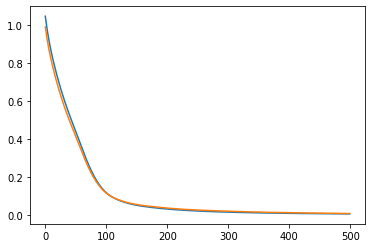

In [5]:
import torch.optim as optim
import tqdm

epochs = 500
model = MLP([x.shape[1], 50, 50, 1], shift=None, init_scale=None)
opt = optim.Adam(model.parameters(), lr=0.001)

def mse_loss(x,y):
    return ((model(x) - y[:,None]) ** 2).mean()

losses = []
losses_val = []
pbar =  tqdm.tqdm(range(epochs))
for i in pbar:
    opt.zero_grad()
    loss = mse_loss(x_train, y_train)
    loss.backward()
    opt.step()
    
    losses.append(loss.item())
    losses_val.append(mse_loss(x_test, y_test).item())
    pbar.set_description(f'Loss: {losses[-1]:.4f}')
    # tqdm.set_description(f'Loss: {loss.item():.4f}')
plt.plot(losses)
plt.plot(losses_val)



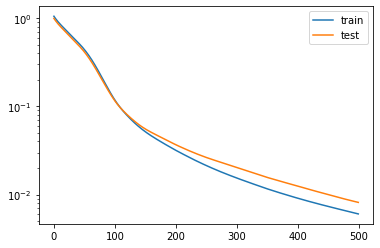

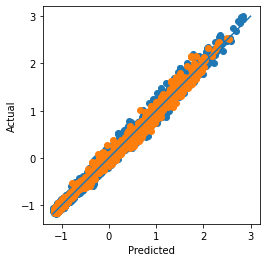

In [6]:
plt.figure()
plt.plot(losses, label='train')
plt.plot(losses_val, label='test')
plt.legend()
plt.yscale('log')

fig, ax = plt.subplots()
plt.scatter(model(x_train).detach().numpy(), y_train.detach().numpy())
plt.scatter(model(x_test).detach().numpy(), y_test.detach().numpy())
min_ = y_centered.min()
max_ = y_centered.max()
range_ = np.linspace(min_, max_, 2)
plt.plot(range_, range_)

plt.xlabel('Predicted')
plt.ylabel('Actual')
ax.set_aspect('equal')

